<a href="https://colab.research.google.com/github/nhglee27/GNNs_Elliptic_Dataset/blob/main/GNNwithClassWeight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx
!pip install torch-geometric
!pip install node2vec
!pip install python-louvain

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd

import random
import torch
import torch_geometric

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import community.community_louvain as community_louvain
import torch.nn.functional as F


from torch import Tensor
from torch_geometric.nn import GCNConv, GATConv
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from torch_geometric.data import Data
from scipy.stats import ttest_ind

print("Torch version:", torch.__version__)
print("Torch Geometric version:", torch_geometric.__version__)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=mpl.MatplotlibDeprecationWarning)

Mounted at /content/drive
Torch version: 2.5.1+cu121
Torch Geometric version: 2.6.1


In [ ]:
from collections import Counter

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Tue_Aug_15_22:02:13_PDT_2023
Cuda compilation tools, release 12.2, V12.2.140
Build cuda_12.2.r12.2/compiler.33191640_0


# ⚙️ Global Settings

In [ ]:
RANDOM_STATE = 42
NUM_EPOCHS = 100

In [ ]:
def set_seed_for_torch(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)      # single-GPU.
        torch.cuda.manual_seed_all(seed)  # multi-GPU.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def set_seed_for_numpy(seed):
    np.random.seed(seed)

def set_seed_for_random(seed):
    random.seed(seed)

In [ ]:
set_seed_for_torch(RANDOM_STATE)
set_seed_for_numpy(RANDOM_STATE)
set_seed_for_random(RANDOM_STATE)

#  Helper Methods

In [ ]:
def train(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


def evaluate(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out.argmax(dim=1)

        correct = (pred[mask] == data.y[mask]).sum().item()
        accuracy = correct / mask.sum().item()

        y_true = data.y[mask].cpu().numpy()
        y_pred = pred[mask].cpu().numpy()

        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

        metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1
        }

    return metrics

def predict(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out.argmax(dim=1)
    return pred

def predict_probabilities(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data)
        probabilities = torch.exp(out)
    return probabilities

In [ ]:
def train_gnn(num_epochs, data, model, optimizer, criterion):

    train_losses = []
    train_accuracies = []
    train_precisions = []
    train_recalls = []
    train_f1_scores = []

    val_accuracies = []
    val_precisions = []
    val_recalls = []
    val_f1_scores = []

    # ----- #
    # Train #
    # ----- #

    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out[data.train_mask],
                         data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # --- Calculate training metrics ---
        pred_train = out[data.train_mask].argmax(dim=1)
        correct_train = (pred_train == data.y[data.train_mask]).sum()
        train_acc = int(correct_train) / int(data.train_mask.sum())
        train_accuracies.append(train_acc)

        y_true_train = data.y[data.train_mask].cpu().numpy()
        y_pred_train = pred_train.cpu().numpy()

        train_prec = precision_score(y_true_train, y_pred_train, average='weighted', zero_division=0)
        train_rec = recall_score(y_true_train, y_pred_train, average='weighted', zero_division=0)
        train_f1 = f1_score(y_true_train, y_pred_train, average='weighted', zero_division=0)

        train_precisions.append(train_prec)
        train_recalls.append(train_rec)
        train_f1_scores.append(train_f1)
        train_losses.append(loss.item())

        # --- Validate and calculate validation metrics ---
        model.eval()
        with torch.no_grad():
            out = model(data)
            pred_val = out[data.val_mask].argmax(dim=1)
            correct_val = (pred_val == data.y[data.val_mask]).sum()
            val_acc = int(correct_val) / int(data.val_mask.sum())
            val_accuracies.append(val_acc)

            y_true_val = data.y[data.val_mask].cpu().numpy()
            y_pred_val = pred_val.cpu().numpy()

            val_prec = precision_score(y_true_val, y_pred_val, average='weighted', zero_division=0)
            val_rec = recall_score(y_true_val, y_pred_val, average='weighted', zero_division=0)
            val_f1 = f1_score(y_true_val, y_pred_val, average='weighted', zero_division=0)

            val_precisions.append(val_prec)
            val_recalls.append(val_rec)
            val_f1_scores.append(val_f1)

        if epoch % 10 == 0:
            print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, Train - Acc: {train_acc:.4f} - Prec: {train_prec:.4f} - Rec: {train_rec:.4f} - F1: {train_f1:.4f}')
            print(f'                         Val   - Acc: {val_acc:.4f} - Prec: {val_prec:.4f} - Rec: {val_rec:.4f} - F1: {val_f1:.4f}')

    return {
        'train': {
            'losses': train_losses,
            'accuracies': train_accuracies,
            'precisions': train_precisions,
            'recalls': train_recalls,
            'f1_scores': train_f1_scores,
        },
        'val': {
            'accuracies': val_accuracies,
            'precisions': val_precisions,
            'recalls': val_recalls,
            'f1_scores': val_f1_scores,
        }
    }

In [ ]:
def plot_train_val_test_metrics(train_val_metrics, test_metrics, num_epochs):
    plt.figure(figsize=(10, 6))

    # --- Accuracy ----
    plt.subplot(2, 2, 1)
    plt.plot(range(1, num_epochs + 1), train_val_metrics['train']['accuracies'], color='C0', linewidth=1.0, label='Training')
    plt.plot(range(1, num_epochs + 1), train_val_metrics['val']['accuracies'], color='C1', linewidth=1.0, label='Validation', linestyle=':')
    plt.axhline(y=test_metrics['accuracy'], color='C2', linewidth=0.5, linestyle='--', label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(fontsize=8)
    plt.title('Accuracy')

    # --- Precision ---
    plt.subplot(2, 2, 2)
    plt.plot(range(1, num_epochs + 1), train_val_metrics['train']['precisions'], color='C0', linewidth=1.0, label='Training')
    plt.plot(range(1, num_epochs + 1), train_val_metrics['val']['precisions'], color='C1', linewidth=1.0, label='Validation', linestyle=':')
    plt.axhline(y=test_metrics['precision'], color='C2', linewidth=0.5, linestyle='--', label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.legend(fontsize=8)
    plt.title('Precision')

    # --- Recall ---
    plt.subplot(2, 2, 3)
    plt.plot(range(1, num_epochs + 1), train_val_metrics['train']['recalls'], color='C0', linewidth=1.0, label='Training')
    plt.plot(range(1, num_epochs + 1), train_val_metrics['val']['recalls'], color='C1', linewidth=1.0, label='Validation', linestyle=':')
    plt.axhline(y=test_metrics['recall'], color='C2', linewidth=0.5, linestyle='--', label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.legend(fontsize=8)
    plt.title('Recall')

    # --- F1-Score ---
    plt.subplot(2, 2, 4)
    plt.plot(range(1, num_epochs + 1), train_val_metrics['train']['f1_scores'], linewidth=1.0, color='C0', label='Training')
    plt.plot(range(1, num_epochs + 1), train_val_metrics['val']['f1_scores'], linewidth=1.0, color='C1', label='Validation', linestyle=':')
    plt.axhline(y=test_metrics['f1_score'], color='C2', linewidth=0.5, linestyle='--', label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('F1-Score')
    plt.legend(fontsize=8)
    plt.title('F1-Score')

    plt.tight_layout()
    plt.show()

#  Overview

In [ ]:
elliptic_txs_features = pd.read_csv('/content/drive/MyDrive/dataset/elliptic_bitcoin_dataset/elliptic_txs_features.csv', header=None)
elliptic_txs_classes = pd.read_csv('/content/drive/MyDrive/dataset/elliptic_bitcoin_dataset/elliptic_txs_classes.csv')
elliptic_txs_edgelist = pd.read_csv('/content/drive/MyDrive/dataset/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv')

elliptic_txs_features.columns = ['txId'] + [f'V{i}' for i in range(1, 167)]

print(f"""Shapes
{4*' '}Features : {elliptic_txs_features.shape[0]:8,} (rows)  {elliptic_txs_features.shape[1]:4,} (cols)
{4*' '}Classes  : {elliptic_txs_classes.shape[0]:8,} (rows)  {elliptic_txs_classes.shape[1]:4,} (cols)
{4*' '}Edgelist : {elliptic_txs_edgelist.shape[0]:8,} (rows)  {elliptic_txs_edgelist.shape[1]:4,} (cols)
""")

Shapes
    Features :  203,769 (rows)   167 (cols)
    Classes  :  203,769 (rows)     2 (cols)
    Edgelist :  234,355 (rows)     2 (cols)



__Nodes & Edges__

- $|V| = 203,768$ (number of nodes in $G$)
- $|E| = 234,355$ (number of edges in $G$)

In [ ]:
elliptic_txs_features.head(3)

,txId,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792


In [ ]:
elliptic_txs_classes.head(3)

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown


In [ ]:
elliptic_txs_edgelist.head(3)

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870


Let's get an overview on the distribution of the `class`es.

In [ ]:
elliptic_txs_classes['class_mapped'] = elliptic_txs_classes['class'].replace({'1': 'illicit', '2': 'licit'})

percentage_distribution = round(100 * elliptic_txs_classes['class_mapped'].value_counts(normalize=True), 2)
class_counts = elliptic_txs_classes['class_mapped'].value_counts()

emoji_mapping = {'licit': '✅', 'illicit': '❌', 'unknown': '🤷'}
elliptic_txs_classes['emoji'] = elliptic_txs_classes['class_mapped'].map(emoji_mapping)

classes_df = pd.DataFrame({
    'Class Mapped': elliptic_txs_classes['class_mapped'].unique(),
    'Class Raw': elliptic_txs_classes['class'].unique(),
    'Counts': class_counts.values,
    'Percentage': percentage_distribution.values,
    'Emoji': [emoji_mapping[class_label] for class_label in elliptic_txs_classes['class_mapped'].unique()]
})
classes_df

,Class Mapped,Class Raw,Counts,Percentage,Emoji
0,unknown,unknown,157205,77.15,🤷
1,licit,2,42019,20.62,✅
2,illicit,1,4545,2.23,❌


- 77.15% of all classes are `unknown`
- 20.62% of all classes are `licit` (2)
- 2.23% of all classes are `illicit` (1)

In [ ]:
num_nodes = elliptic_txs_features.shape[0]
num_edges = elliptic_txs_edgelist.shape[0]

print(f"Number of nodes: {num_nodes:,}")
print(f"Number of edges: {num_edges:,}")

Number of nodes: 203,769
Number of edges: 234,355


In [ ]:
G = nx.from_pandas_edgelist(elliptic_txs_edgelist, 'txId1', 'txId2')

In [ ]:
classes_sampled = elliptic_txs_classes.groupby('class_mapped').sample(frac=0.05, random_state=RANDOM_STATE)
txIds_sampled = classes_sampled['txId']

edgelist_sampled = elliptic_txs_edgelist[
    elliptic_txs_edgelist['txId1'].isin(txIds_sampled) | elliptic_txs_edgelist['txId2'].isin(txIds_sampled)
]

features_sampled = elliptic_txs_features[elliptic_txs_features['txId'].isin(txIds_sampled)]

print(f"Sampled Classes:\n{classes_sampled['class_mapped'].value_counts()}\n")
print(f"Sampled Edgelist: {edgelist_sampled.shape[0]:,}")
print(f"Sampled Features: {features_sampled.shape[0]:,}")

Sampled Classes:
class_mapped
unknown    7860
licit      2101
illicit     227
Name: count, dtype: int64

Sampled Edgelist: 23,051
Sampled Features: 10,188


# Exploratory Data Analysis (EDA)

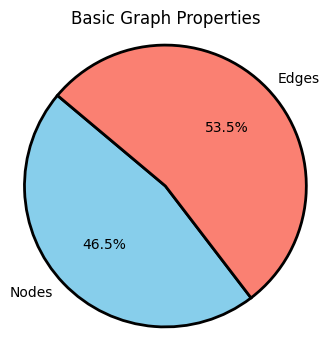

In [ ]:
plt.figure(figsize=(4, 4))
sizes = [num_nodes, num_edges]
labels = ['Nodes', 'Edges']
colors = ['skyblue', 'salmon']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140,
        wedgeprops = {'edgecolor' : 'black',
                      'linewidth': 2,
                      'antialiased': True})
plt.title('Basic Graph Properties')
plt.axis('equal')
plt.show()

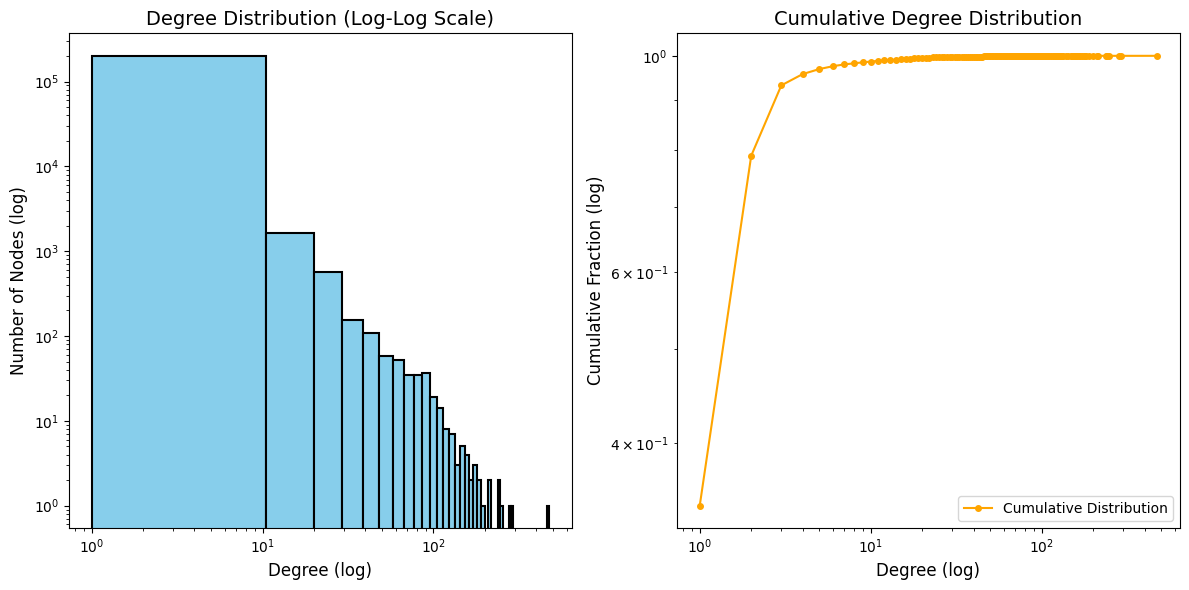

Estimated Power-law Parameter (γ): 3.24
Low-degree Nodes: 190017
High-degree Nodes: 13752


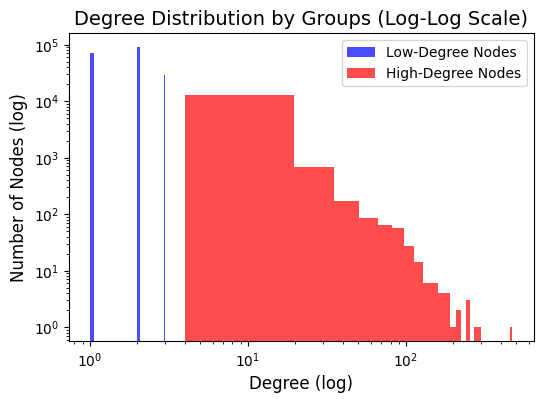

In [ ]:
# --- Degree Distribution (Log-Log Scale) ---
plt.figure(figsize=(12, 6))
degrees = [G.degree(n) for n in G.nodes()]

# Histogram of degrees (Log-Log Scale)
plt.subplot(1, 2, 1)
plt.hist(degrees, bins=50, log=True, color='skyblue', edgecolor='black', linewidth=1.5)
plt.xscale('log')
plt.yscale('log')
plt.title('Degree Distribution (Log-Log Scale)', fontsize=14)
plt.xlabel('Degree (log)', fontsize=12)
plt.ylabel('Number of Nodes (log)', fontsize=12)

# --- Cumulative Degree Distribution ---
plt.subplot(1, 2, 2)
degree_counts = Counter(degrees)
x = np.array(sorted(degree_counts.keys()))
y = np.array([degree_counts[d] for d in x]).cumsum()
y = y / y[-1]  # Normalize cumulative values
plt.plot(x, y, 'o-', color='orange', markersize=4, label='Cumulative Distribution')
plt.xscale('log')
plt.yscale('log')
plt.title('Cumulative Degree Distribution', fontsize=14)
plt.xlabel('Degree (log)', fontsize=12)
plt.ylabel('Cumulative Fraction (log)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

# --- Power-law Analysis ---
from scipy.optimize import curve_fit

# Function to fit power-law: P(k) ~ k^(-gamma)
def power_law(x, gamma, c):
    return c * np.power(x, -gamma)

# Fit the degree distribution
xdata = x[x > 1]  # Exclude degree = 0 or 1
ydata = np.array([degree_counts[d] for d in xdata])
params, covariance = curve_fit(power_law, xdata, ydata)

gamma, c = params
print(f"Estimated Power-law Parameter (γ): {gamma:.2f}")

# --- Highlight Low- vs High-Degree Nodes ---
high_degree_threshold = np.percentile(degrees, 90)  # Top 10% as high-degree
low_degree_nodes = [n for n in G.nodes() if G.degree(n) <= high_degree_threshold]
high_degree_nodes = [n for n in G.nodes() if G.degree(n) > high_degree_threshold]

print(f"Low-degree Nodes: {len(low_degree_nodes)}")
print(f"High-degree Nodes: {len(high_degree_nodes)}")

# Visualize degree groups
plt.figure(figsize=(6, 4))
plt.hist(
    [G.degree(n) for n in low_degree_nodes],
    bins=30, alpha=0.7, label="Low-Degree Nodes", color="blue", log=True
)
plt.hist(
    [G.degree(n) for n in high_degree_nodes],
    bins=30, alpha=0.7, label="High-Degree Nodes", color="red", log=True
)
plt.xscale("log")
plt.yscale("log")
plt.title("Degree Distribution by Groups (Log-Log Scale)", fontsize=14)
plt.xlabel("Degree (log)", fontsize=12)
plt.ylabel("Number of Nodes (log)", fontsize=12)
plt.legend()
plt.show()

Number of nodes: 10,188
Number of edges: 23,051


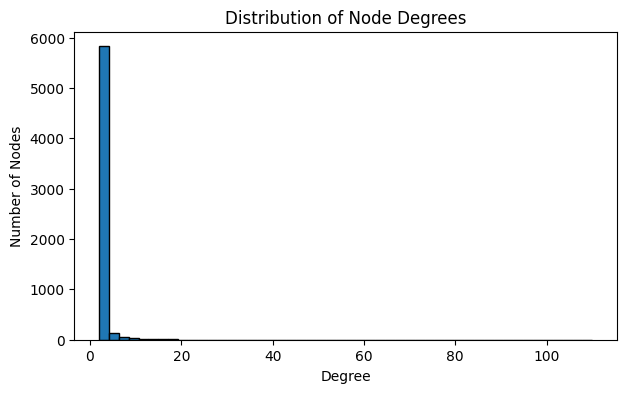

In [ ]:
num_nodes = features_sampled.shape[0]
num_edges = edgelist_sampled.shape[0]

print(f"Number of nodes: {num_nodes:,}")
print(f"Number of edges: {num_edges:,}")

plt.figure(figsize=(7, 4))

node_degrees = edgelist_sampled['txId1'].value_counts() + edgelist_sampled['txId2'].value_counts()
node_degrees.hist(bins=50, edgecolor='black')
plt.title('Distribution of Node Degrees')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.grid(False)
plt.show()

## Graph Connectivity

In [ ]:
# Tạo đồ thị từ edgelist.
G = nx.from_pandas_edgelist(edgelist_sampled, 'txId1', 'txId2')

Số connected components: 7297
Giant component - Number of nodes: 400
Giant component - Number of edges: 431


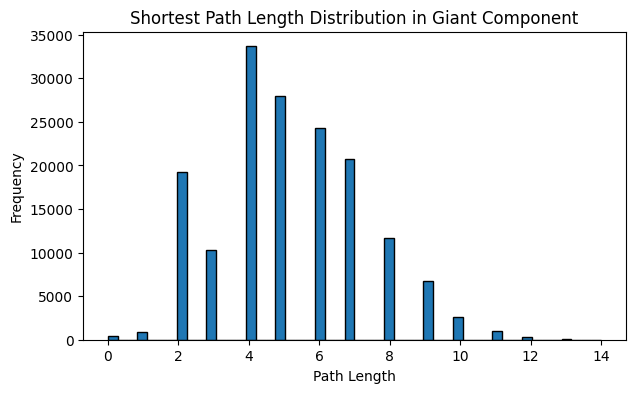

In [ ]:
num_connected_components = nx.number_connected_components(G)
print(f"Số connected components: {num_connected_components}")

# --- Giant component analysis ---
giant_component = max(nx.connected_components(G), key=len)
G_giant = G.subgraph(giant_component)

print(f"Giant component - Number of nodes: {G_giant.number_of_nodes():,}")
print(f"Giant component - Number of edges: {G_giant.number_of_edges():,}")


# --------------------------------------------------------- #
# Shortest paths length distribution in the giant component #
# --------------------------------------------------------- #
path_lengths = dict(nx.shortest_path_length(G_giant))
path_lengths_values = [length for target_lengths in path_lengths.values() for length in target_lengths.values()]

plt.figure(figsize=(7, 4))
plt.hist(path_lengths_values, bins=50, edgecolor='black')
plt.title('Shortest Path Length Distribution in Giant Component')
plt.xlabel('Path Length')
plt.ylabel('Frequency')
plt.show()

## Node Centrality Measures

Top 10 nodes by degree centrality:
        Node  Degree Centrality
0   22837965           0.275689
1   22837835           0.192982
2  279199578           0.030075
3    3807285           0.027569
4  279187194           0.027569
5   22837973           0.022556
6   90716926           0.022556
7    8128388           0.022556
8   22837808           0.020050
9   22838007           0.020050


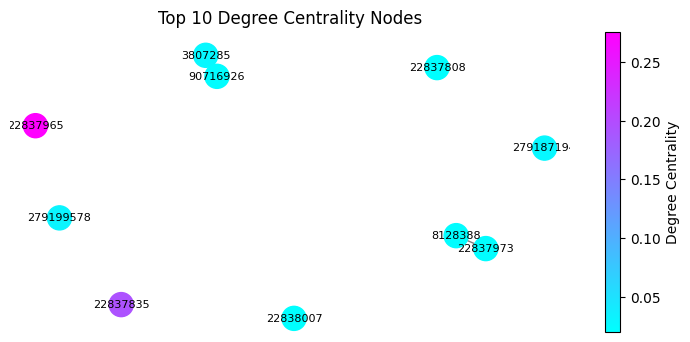

In [ ]:
# Degree centrality.
degree_centrality = nx.degree_centrality(G_giant)
top_degree_centrality = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
df_top_degree_centrality = pd.DataFrame(top_degree_centrality, columns=['Node', 'Degree Centrality'])

print("Top 10 nodes by degree centrality:")
print("==================================")
print(df_top_degree_centrality)

top_nodes_by_ = df_top_degree_centrality['Node'].tolist()
subgraph = G_giant.subgraph(top_nodes_by_)
node_color = [degree_centrality[node] for node in subgraph.nodes()]
norm = mpl.colors.Normalize(vmin=min(node_color), vmax=max(node_color))
node_color_normalized = [norm(value) for value in node_color]
cmap = plt.cm.cool

# -------- #
# Plotting #
# -------- #
plt.figure(figsize=(7, 3))

# Vẽ đồ thị
pos = nx.spring_layout(subgraph)  # Tạo layout để giữ vị trí các node
nx.draw(subgraph, pos, with_labels=True, node_size=300, edge_color='gray', font_size=8,
        node_color=node_color, cmap=cmap)

# Tạo ScalarMappable để dùng cho colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Gắn colorbar vào trục hiện tại (gca)
plt.colorbar(sm, ax=plt.gca(), label='Degree Centrality')

plt.title('Top 10 Degree Centrality Nodes')
plt.show()

Top 10 nodes by betweenness centrality:
        Node  Betweenness Centrality
0   22837835                0.553959
1   22837965                0.491607
2   90716926                0.166458
3   22837784                0.165590
4  279187194                0.164591
5    3807285                0.144993
6    3097782                0.113509
7    8128388                0.103709
8    1435388                0.092219
9   21296808                0.086872


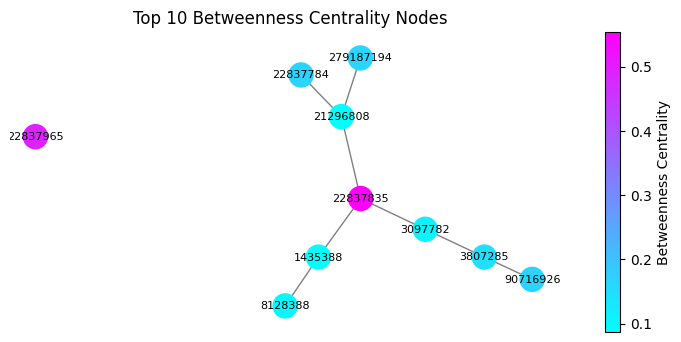

In [ ]:
# Betweenness centrality.
betweenness_centrality = nx.betweenness_centrality(G_giant)
top_betweenness_centrality = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
df_top_betweenness_centrality = pd.DataFrame(top_betweenness_centrality, columns=['Node', 'Betweenness Centrality'])

print("Top 10 nodes by betweenness centrality:")
print("=======================================")
print(df_top_betweenness_centrality)

top_nodes_by_ = df_top_betweenness_centrality['Node'].tolist()
subgraph = G_giant.subgraph(top_nodes_by_)
node_color = [betweenness_centrality[node] for node in subgraph.nodes()]
norm = mpl.colors.Normalize(vmin=min(node_color), vmax=max(node_color))
node_color_normalized = [norm(value) for value in node_color]
cmap = plt.cm.cool

# -------- #
# Plotting #
# -------- #
plt.figure(figsize=(7, 3))

# Vẽ đồ thị với pos để giữ vị trí node
pos = nx.spring_layout(subgraph)
nx.draw(subgraph, pos, with_labels=True, node_size=300, edge_color='gray', font_size=8,
        node_color=node_color, cmap=cmap)

# Tạo ScalarMappable để dùng cho colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Gắn colorbar vào trục hiện tại (gca)
plt.colorbar(sm, ax=plt.gca(), label='Betweenness Centrality')

plt.title('Top 10 Betweenness Centrality Nodes')
plt.show()

Top 10 nodes by closeness centrality:
        Node  Closeness Centrality
0   22837835              0.317928
1   22837965              0.293814
2    2203811              0.290605
3    1805107              0.285817
4   11447640              0.285817
5    2205152              0.285817
6    1367537              0.285817
7    1437191              0.285817
8   21296808              0.274038
9  279187194              0.271613


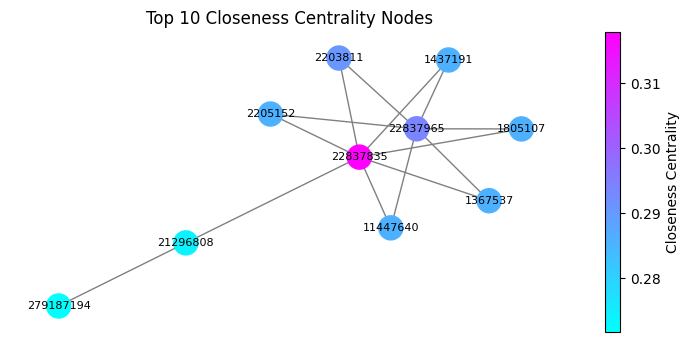

In [ ]:
# Closeness centrality.
closeness_centrality = nx.closeness_centrality(G_giant)
top_closeness_centrality = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
df_top_closeness_centrality = pd.DataFrame(top_closeness_centrality, columns=['Node', 'Closeness Centrality'])

print("Top 10 nodes by closeness centrality:")
print("=====================================")
print(df_top_closeness_centrality)

top_nodes_by_closeness = df_top_closeness_centrality['Node'].tolist()
subgraph = G_giant.subgraph(top_nodes_by_closeness)
node_color = [closeness_centrality[node] for node in subgraph.nodes()]
norm = mpl.colors.Normalize(vmin=min(node_color), vmax=max(node_color))
node_color_normalized = [norm(value) for value in node_color]
cmap = plt.cm.cool

# -------- #
# Plotting #
# -------- #
plt.figure(figsize=(7, 3))

# Tạo layout cho đồ thị
pos = nx.spring_layout(subgraph)

# Vẽ đồ thị với node_color được tính từ closeness_centrality
nx.draw(subgraph, pos, with_labels=True, node_size=300, edge_color='gray', font_size=8,
        node_color=node_color, cmap=cmap)

# Tạo ScalarMappable để gắn colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Gắn colorbar vào trục hiện tại
plt.colorbar(sm, ax=plt.gca(), label='Closeness Centrality')

plt.title('Top 10 Closeness Centrality Nodes')
plt.show()

## Graph Visualization

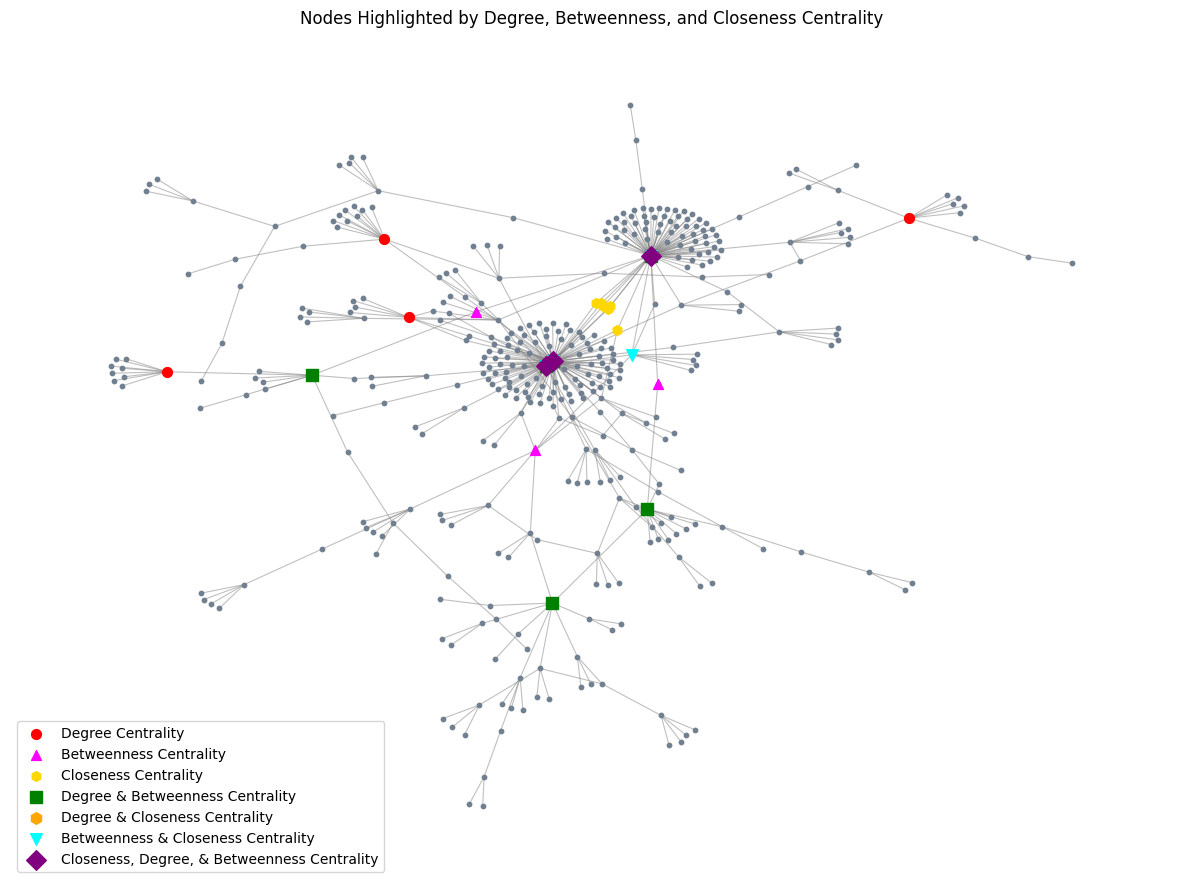

In [ ]:
# --------- #
# Preparing #
# --------- #

# Identify nodes that are top in each centrality measure and their combinations.
top_nodes_degree = set([node for node, _ in top_degree_centrality])
top_nodes_betweenness = set([node for node, _ in top_betweenness_centrality])
top_nodes_closeness = set([node for node, _ in top_closeness_centrality])

top_nodes_both = top_nodes_degree.intersection(top_nodes_betweenness)
top_nodes_closeness_and_degree = top_nodes_closeness.intersection(top_nodes_degree)
top_nodes_closeness_and_betweenness = top_nodes_closeness.intersection(top_nodes_betweenness)
top_nodes_all_three = top_nodes_closeness.intersection(top_nodes_degree).intersection(top_nodes_betweenness)

# Assign colors and shapes based on centrality measures.
node_color = []
node_shape = []

for node in G_giant.nodes():
    if node in top_nodes_all_three:
        node_color.append('purple')
        node_shape.append('D')
    elif node in top_nodes_closeness_and_degree:
        node_color.append('orange')
        node_shape.append('h')
    elif node in top_nodes_closeness_and_betweenness:
        node_color.append('cyan')
        node_shape.append('v')
    elif node in top_nodes_both:
        node_color.append('green')
        node_shape.append('s')
    elif node in top_nodes_degree:
        node_color.append('red')
        node_shape.append('o')
    elif node in top_nodes_betweenness:
        node_color.append('magenta')
        node_shape.append('^')
    elif node in top_nodes_closeness:
        node_color.append('yellow')
        node_shape.append('h')
    else:
        node_color.append('slategrey')
        node_shape.append('o')

# -------- #
# Plotting #
# -------- #

plt.figure(figsize=(15, 11))

pos = nx.spring_layout(G_giant)
# Draw all nodes first.
nx.draw_networkx_nodes(G_giant, pos, node_color='slategrey', node_size=10)

# Draw nodes with specific centrality measures.
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_degree - top_nodes_both - top_nodes_closeness_and_degree),
                       node_color='red', node_size=50, node_shape='o',
                       label='Degree Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_betweenness - top_nodes_both - top_nodes_closeness_and_betweenness),
                       node_color='magenta', node_size=50, node_shape='^',
                       label='Betweenness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_closeness - top_nodes_closeness_and_degree - top_nodes_closeness_and_betweenness),
                       node_color='gold', node_size=50, node_shape='h',
                       label='Closeness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_both),
                       node_color='green', node_size=80, node_shape='s',
                       label='Degree & Betweenness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_closeness_and_degree),
                       node_color='orange', node_size=70, node_shape='h',
                       label='Degree & Closeness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_closeness_and_betweenness),
                       node_color='cyan', node_size=70, node_shape='v',
                       label='Betweenness & Closeness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_all_three),
                       node_color='purple', node_size=100, node_shape='D',
                       label='Closeness, Degree, & Betweenness Centrality')

# Draw edges.
nx.draw_networkx_edges(G_giant, pos, width=0.8, edge_color='gray', alpha=0.5)

plt.axis('off')
plt.title('Nodes Highlighted by Degree, Betweenness, and Closeness Centrality')
plt.legend(scatterpoints=1)
plt.show()

## Class-specific Analysis

In [ ]:
# Class-based subgraphs.
illicit_nodes = classes_sampled[classes_sampled['class_mapped'] == 'illicit']['txId']
licit_nodes = classes_sampled[classes_sampled['class_mapped'] == 'licit']['txId']

G_illicit = G.subgraph(illicit_nodes)
G_licit = G.subgraph(licit_nodes)

In [ ]:
classes_df

,Class Mapped,Class Raw,Counts,Percentage,Emoji
0,unknown,unknown,157205,77.15,🤷
1,licit,2,42019,20.62,✅
2,illicit,1,4545,2.23,❌


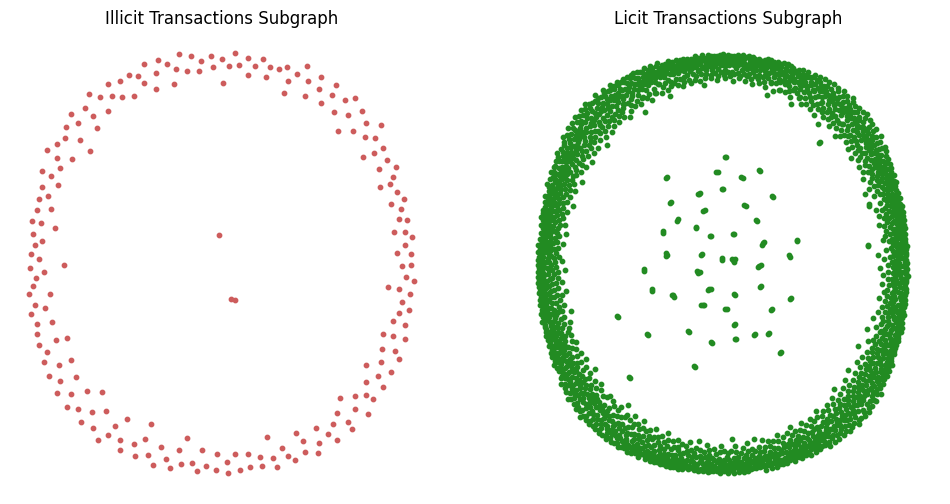

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
nx.draw(G_illicit, with_labels=False, node_size=10, node_color='indianred', edge_color='black')
plt.title('Illicit Transactions Subgraph')

plt.subplot(1, 2, 2)
nx.draw(G_licit, with_labels=False, node_size=10, node_color='forestgreen', edge_color='black')
plt.title('Licit Transactions Subgraph')

plt.show()

__❌ Biểu đồ giao dịch bất hợp pháp__
- Hiển thị sự phân bố khá thưa thớt của các nút, với một mẫu hình vòng tròn.
- Hầu hết các nút đều ở ngoại vi và một số nút tập trung ở trung tâm.
- Gợi ý rằng __các giao dịch bất hợp pháp có thể ít được kết nối với nhau__, với một __vài nút trung tâm có khả năng hoạt động như các trung tâm__ hoặc các điểm chính trong mạng.

__✅ Biểu đồ giao dịch hợp pháp__
- Mật độ nút cao hơn gợi ý một mạng lưới phức tạp hơn với nhiều giao dịch hoặc tương tác giữa các thực thể hơn.
- Có thể ngụ ý một mạng lưới được thiết lập hoặc hợp pháp hơn.
- Gợi ý rằng các giao dịch hợp pháp có thể liên quan đến nhiều thực thể được kết nối với nhau hơn, với nhiều nút có mối quan hệ chặt chẽ hoặc tương tác thường xuyên hơn.


# Community Detection


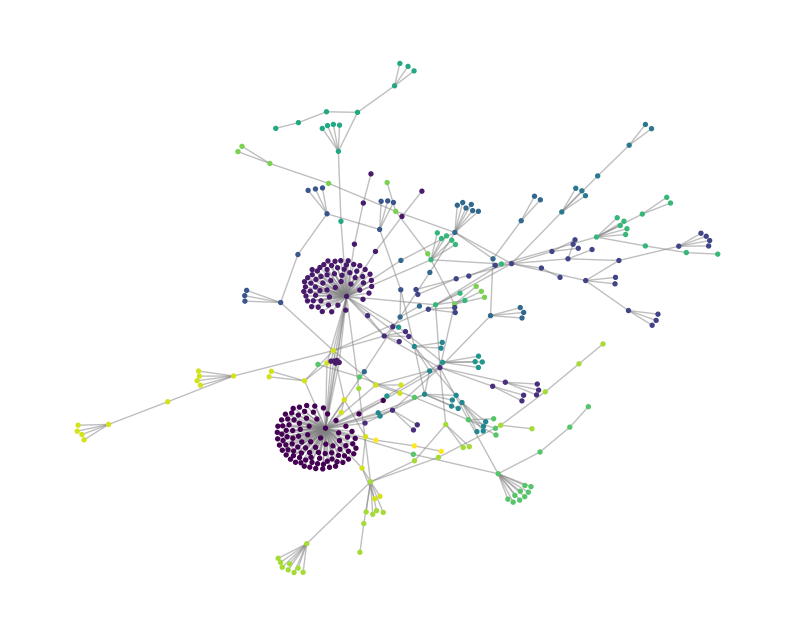

In [ ]:
# Compute best partition.
partition = community_louvain.best_partition(G_giant)

# Draw graph.
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_giant)
cmap = plt.get_cmap('viridis')
nx.draw_networkx_nodes(G_giant, pos, node_color=list(partition.values()), node_size=8, cmap=cmap)
nx.draw_networkx_edges(G_giant, pos, alpha=0.5, edge_color='grey')
plt.axis('off')

plt.show()

#  Graph Neural Networks


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
metrics_per_gnn = {
    'gcn': {
        'val': {
            'precisions': [],
            'probas': [],
        },
        'test': {
            'licit': {
                'probas': []
            },
            'illicit': {
                'probas': []
            },
        }
    },
    'gat': {
        'val': {
            'precisions': [],
            'probas': [],
        },
        'test': {
            'licit': {
                'probas': []
            },
            'illicit': {
                'probas': []
            },
        }
    },
    'gin': {
        'val': {
            'precisions': [],
            'probas': [],
        },
        'test': {
            'licit': {
                'probas': []
            },
            'illicit': {
                'probas': []
            },
        }
    }
}

## Pre-Processing

In [ ]:
num_edges = elliptic_txs_edgelist.shape[0]
num_nodes = elliptic_txs_features.shape[0]

print(f'Number of edges in the graph: {num_edges:8,}')
print(f'Number of nodes in the graph: {num_nodes:8,}')

Number of edges in the graph:  234,355
Number of nodes in the graph:  203,769


In [ ]:
# --------------------------------------------------------- #
# Create mapping with txId as key and actual index as value #
# --------------------------------------------------------- #

tx_id_mapping = {tx_id: idx for idx, tx_id in enumerate(elliptic_txs_features['txId'])}

edges_with_features = elliptic_txs_edgelist[elliptic_txs_edgelist['txId1'].isin(list(tx_id_mapping.keys()))\
                                          & elliptic_txs_edgelist['txId2'].isin(list(tx_id_mapping.keys()))]

edges_with_features['Id1'] = edges_with_features['txId1'].map(tx_id_mapping)
edges_with_features['Id2'] = edges_with_features['txId2'].map(tx_id_mapping)

edges_with_features

,txId1,txId2,Id1,Id2
0,230425980,5530458,0,1
1,232022460,232438397,2,3
2,230460314,230459870,4,5
3,230333930,230595899,6,7
4,232013274,232029206,8,9
...,...,...,...,...
234350,158365409,157930723,203602,201430
234351,188708874,188708879,203603,203099
234352,157659064,157659046,201921,202042
234353,87414554,106877725,201480,201368


In [ ]:
edge_index = torch.tensor(edges_with_features[['Id1', 'Id2']].values.T, dtype=torch.long)
edge_index

tensor([[     0,      2,      4,  ..., 201921, 201480, 201954],
        [     1,      3,      5,  ..., 202042, 201368, 201756]])

In [ ]:
# ------------------------------------- #
# Save node features in suitable format #
# ------------------------------------- #

node_features = torch.tensor(elliptic_txs_features.drop(columns=['txId']).values,
                             dtype=torch.float)
print(node_features.shape)
node_features

torch.Size([203769, 166])


tensor([[ 1.0000e+00, -1.7147e-01, -1.8467e-01,  ..., -9.7524e-02,
         -1.2061e-01, -1.1979e-01],
        [ 1.0000e+00, -1.7148e-01, -1.8467e-01,  ..., -9.7524e-02,
         -1.2061e-01, -1.1979e-01],
        [ 1.0000e+00, -1.7211e-01, -1.8467e-01,  ..., -1.8367e-01,
         -1.2061e-01, -1.1979e-01],
        ...,
        [ 4.9000e+01, -1.7201e-01, -7.8182e-02,  ..., -9.7524e-02,
         -1.2061e-01, -1.1979e-01],
        [ 4.9000e+01, -1.7284e-01, -1.7662e-01,  ..., -1.4060e-01,
          1.5197e+00,  1.5214e+00],
        [ 4.9000e+01, -1.2037e-02, -1.3228e-01,  ..., -1.4060e-01,
          1.5197e+00,  1.5214e+00]])

- Chiều thứ nhất cho chúng ta biết về `# of nodes`
- Chiều thứ hai cho chúng ta biết về `# of node features`

In [ ]:
elliptic_txs_classes['class'].value_counts()

,count
class,
unknown,157205
2,42019
1,4545


In [ ]:
# ------------------------ #
# Labelencode target class #
# ------------------------ #

le = LabelEncoder()
class_labels = le.fit_transform(elliptic_txs_classes['class'])
node_labels = torch.tensor(class_labels, dtype=torch.long)
original_labels = le.inverse_transform(class_labels)

print(original_labels)
print(class_labels)
print(node_labels)

['unknown' 'unknown' 'unknown' ... '1' 'unknown' 'unknown']
[2 2 2 ... 0 2 2]
tensor([2, 2, 2,  ..., 0, 2, 2])


In [ ]:
print(le.inverse_transform([0])) # illicit
print(le.inverse_transform([1])) # licit
print(le.inverse_transform([2])) # unknown

['1']
['2']
['unknown']


In [ ]:
# ------------------------------------ #
# Create pytorch geometric Data object #
# ------------------------------------ #

data = Data(x=node_features, edge_index=edge_index, y=node_labels)

# Move data to GPU.
data = data.to(device)

In [ ]:
known_mask   = (data.y == 0) | (data.y == 1)  # Only nodes with known labels licit or illicit
unknown_mask = data.y == 2                    # Nodes with unknown labels

In [ ]:
# ------------------------------------------------ #
# Define size for Training, Validation and Testing #
# ------------------------------------------------ #

num_known_nodes = known_mask.sum().item()
permutations = torch.randperm(num_known_nodes)
train_size = int(0.8 * num_known_nodes)
val_size = int(0.1 * num_known_nodes)
test_size = num_known_nodes - train_size - val_size

total = np.sum([train_size, val_size, test_size])

print(f"""Number of observations per split
    Training   : {train_size:10,} ({100*train_size/total:0.2f} %)
    Validation : {val_size:10,} ({100*val_size/total:0.2f} %)
    Testing    : {test_size:10,} ({100*test_size/total:0.2f} %)
""")

Number of observations per split
    Training   :     37,251 (80.00 %)
    Validation :      4,656 (10.00 %)
    Testing    :      4,657 (10.00 %)



In [ ]:
# ----------------------------------------------- #
# Create mask for the indices of Train, Val, Test #
# ----------------------------------------------- #

data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

train_indices = known_mask.nonzero(as_tuple=True)[0][permutations[:train_size]]
val_indices = known_mask.nonzero(as_tuple=True)[0][permutations[train_size:train_size + val_size]]
test_indices = known_mask.nonzero(as_tuple=True)[0][permutations[train_size + val_size:]]

data.train_mask[train_indices] = True
data.val_mask[val_indices] = True
data.test_mask[test_indices] = True

data.train_mask

tensor([False, False, False,  ...,  True, False, False])

In [ ]:
# -------------------------- #
# Statistics of the datasets #
# -------------------------- #

train_licit, train_illicit = (data.y[data.train_mask] == 1).sum().item(), (data.y[data.train_mask] == 0).sum().item()
val_licit, val_illicit = (data.y[data.val_mask] == 1).sum().item(), (data.y[data.val_mask] == 0).sum().item()
test_licit, test_illicit = (data.y[data.test_mask] == 1).sum().item(), (data.y[data.test_mask] == 0).sum().item()

# Calculate total counts.
train_total = train_licit + train_illicit
val_total = val_licit + val_illicit
test_total = test_licit + test_illicit

# Calculate percentages.
train_licit_pct = (train_licit / train_total) * 100
train_illicit_pct = (train_illicit / train_total) * 100
val_licit_pct = (val_licit / val_total) * 100
val_illicit_pct = (val_illicit / val_total) * 100
test_licit_pct = (test_licit / test_total) * 100
test_illicit_pct = (test_illicit / test_total) * 100

pd.DataFrame({
    'Set': ['Training', 'Validation', 'Testing'],
    'Total Count': [train_total, val_total, test_total],
    'Licit': [train_licit, val_licit, test_licit],
    'Licit (%)': [train_licit_pct, val_licit_pct, test_licit_pct],
    'Illicit': [train_illicit, val_illicit, test_illicit],
    'Illicit (%)': [train_illicit_pct, val_illicit_pct, test_illicit_pct]
})

,Set,Total Count,Licit,Licit (%),Illicit,Illicit (%)
0,Training,37251,33649,90.330461,3602,9.669539
1,Validation,4656,4148,89.089347,508,10.910653
2,Testing,4657,4222,90.659223,435,9.340777


In [ ]:
mapped_classes = np.array(['illicit', 'licit'])

## 1️ GCN - Graph Convolutional Networks


In [ ]:
# -------------- #
# Define the GCN #
# -------------- #

class GCN(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


# Tính số lượng mẫu của mỗi lớp
class_counts = torch.bincount(data.y)  # Đếm số lượng mỗi nhãn trong tập dữ liệu
class_weights = 1. / class_counts.float()  # Trọng số ngược với tần suất

# In trọng số lớp để kiểm tra
print(f"Class counts: {class_counts}")
print(f"Class weights: {class_weights}")

# Khởi tạo hàm mất mát với trọng số
criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

model = GCN(num_node_features=data.num_features, num_classes=len(le.classes_)).to(device)E
optimizer = torch.optim.Adam(model.parameters(),
                             lr=0.01,
                             weight_decay=0.0005)

data = data.to(device)

Class counts: tensor([  4545,  42019, 157205])
Class weights: tensor([2.2002e-04, 2.3799e-05, 6.3611e-06])


In [ ]:
# ----- #
# Train #
# ----- #

train_val_metrics = train_gnn(NUM_EPOCHS,
                              data,
                              model,
                              optimizer,
                              criterion)

metrics_per_gnn['gcn']['val']['precisions'] = train_val_metrics['val']['precisions']

Epoch 010, Loss: 0.5186, Train - Acc: 0.7286 - Prec: 0.9063 - Rec: 0.7286 - F1: 0.7830
                         Val   - Acc: 0.7098 - Prec: 0.9026 - Rec: 0.7098 - F1: 0.7641
Epoch 020, Loss: 0.4604, Train - Acc: 0.8258 - Prec: 0.9132 - Rec: 0.8258 - F1: 0.8547
                         Val   - Acc: 0.8258 - Prec: 0.9079 - Rec: 0.8258 - F1: 0.8520
Epoch 030, Loss: 0.3962, Train - Acc: 0.7771 - Prec: 0.9191 - Rec: 0.7771 - F1: 0.8201
                         Val   - Acc: 0.7897 - Prec: 0.9116 - Rec: 0.7897 - F1: 0.8259
Epoch 040, Loss: 0.3659, Train - Acc: 0.7898 - Prec: 0.9212 - Rec: 0.7898 - F1: 0.8296
                         Val   - Acc: 0.7878 - Prec: 0.9133 - Rec: 0.7878 - F1: 0.8246
Epoch 050, Loss: 0.3413, Train - Acc: 0.8208 - Prec: 0.9239 - Rec: 0.8208 - F1: 0.8526
                         Val   - Acc: 0.8162 - Prec: 0.9167 - Rec: 0.8162 - F1: 0.8461
Epoch 060, Loss: 0.3209, Train - Acc: 0.8363 - Prec: 0.9267 - Rec: 0.8363 - F1: 0.8642
                         Val   - Acc: 0.825

In [ ]:
# -------- #
# Evaluate #
# -------- #

model.eval()
with torch.no_grad():

    test_metrics = evaluate(model, data, data.test_mask)
    test_acc = test_metrics.get('accuracy')
    test_prec = test_metrics.get('precision')
    test_rec = test_metrics.get('recall')
    test_f1 = test_metrics.get('f1_score')

    print(f'Test Acc: {test_acc:.4f} - Prec: {test_prec:.4f} - Rec: {test_rec:.4f} - F1: {test_f1:.4f}')

Test Acc: 0.8735 - Prec: 0.9346 - Rec: 0.8735 - F1: 0.8926


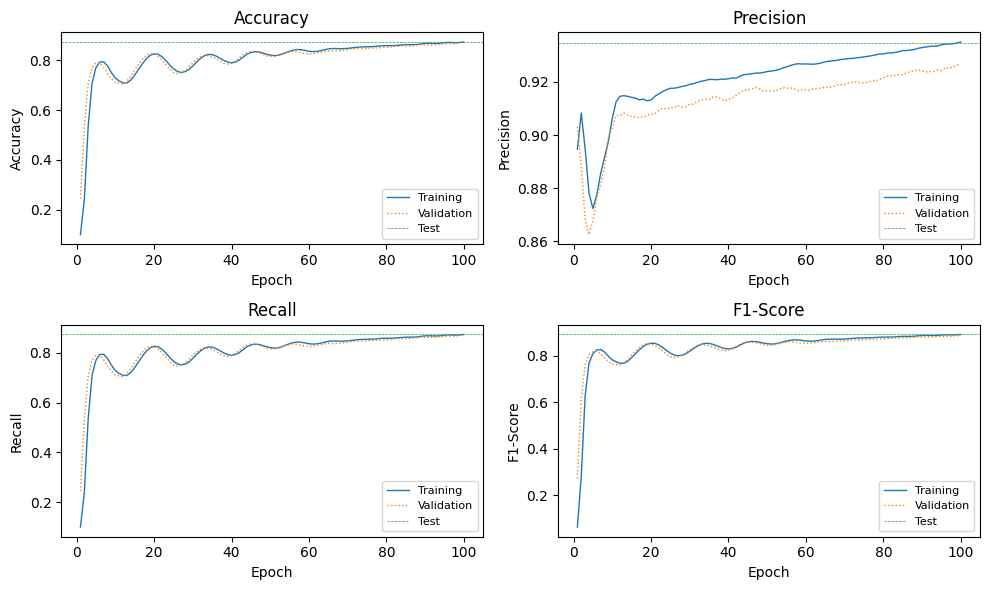

In [ ]:
plot_train_val_test_metrics(train_val_metrics, test_metrics, NUM_EPOCHS)

In [ ]:
train_pred = predict(model, data)[data.train_mask]
test_pred = predict(model, data)[data.test_mask]

In [ ]:
print(le.inverse_transform([0])) # illicit
print(le.inverse_transform([1])) # licit
print(le.inverse_transform([2])) # unknown

['1']
['2']
['unknown']


In [ ]:
# --- Classification report ---
print("Classification Report")
print("=====================\n")

# Train.
y_true_train = data.y[data.train_mask].cpu().numpy()
y_pred_train = train_pred.cpu().numpy()

report_train = classification_report(y_true_train, y_pred_train, target_names=mapped_classes)

print(f"{4*' '}TRAIN")
print("---------")
print(report_train)

# Test.
y_true_test = data.y[data.test_mask].cpu().numpy()
y_pred_test = test_pred.cpu().numpy()

report_test = classification_report(y_true_test, y_pred_test, target_names=mapped_classes)

print(f"{4*' '}TEST")
print("--------")
print(report_test)

Classification Report

    TRAIN
---------
              precision    recall  f1-score   support

     illicit       0.43      0.91      0.58      3602
       licit       0.99      0.87      0.93     33649

    accuracy                           0.87     37251
   macro avg       0.71      0.89      0.75     37251
weighted avg       0.94      0.87      0.89     37251

    TEST
--------
              precision    recall  f1-score   support

     illicit       0.42      0.90      0.57       435
       licit       0.99      0.87      0.93      4222

    accuracy                           0.87      4657
   macro avg       0.70      0.88      0.75      4657
weighted avg       0.93      0.87      0.89      4657



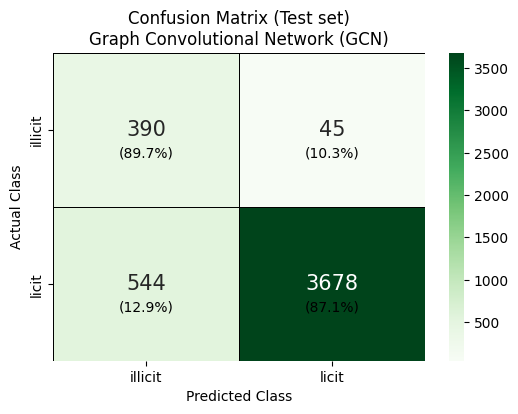

In [ ]:
mapped_classes = np.array(['illicit', 'licit'])

# --- Confusion matrix ---
cm = confusion_matrix(data.y[data.test_mask].cpu(), test_pred.cpu())

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='g', cmap=plt.cm.Greens,
            annot_kws={'size': 15},
            xticklabels=mapped_classes,
            yticklabels=mapped_classes,
            linecolor='black', linewidth=0.5,
            ax=ax)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

# Annotate each cell with the percentage of that row.
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percentage = cm_normalized[i, j] * 100
        text = f'\n({percentage:.1f}%)'
        color = 'white' if percentage > 95 else 'black'
        ax.text(j + 0.5, i + 0.6, text,
                ha='center', va='center', fontsize=10, color=color)

plt.title('Confusion Matrix (Test set)\nGraph Convolutional Network (GCN)')
plt.show()

In [ ]:
train_probas = predict_probabilities(model, data)[data.train_mask]
test_probas = predict_probabilities(model, data)[data.test_mask]

In [ ]:
train_probas_illicit = train_probas[:, 1].cpu().numpy()
train_probas_illicit

array([1.        , 1.        , 0.50784945, ..., 0.998835  , 0.95415336,
       0.25751138], dtype=float32)

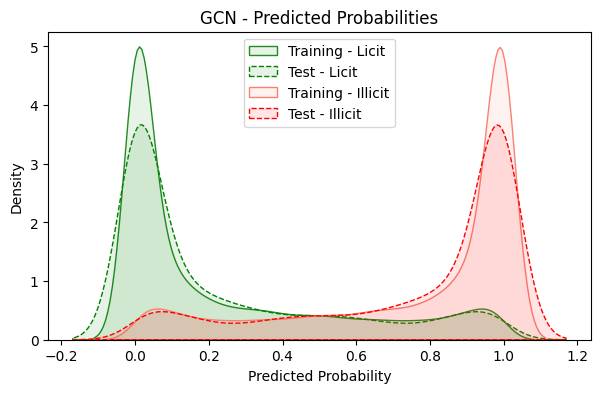

In [ ]:
ALPHA = 0.1

train_probas_licit = train_probas[:, 0].cpu().numpy()
train_probas_illicit = train_probas[:, 1].cpu().numpy()

test_probas_licit = test_probas[:, 0].cpu().numpy()
test_probas_illicit = test_probas[:, 1].cpu().numpy()

metrics_per_gnn['gcn']['test']['licit']['probas'] = test_probas_licit
metrics_per_gnn['gcn']['test']['illicit']['probas'] = test_probas_illicit

# -------- #
# Plotting #
# -------- #

plt.figure(figsize=(7, 4))

# Plot licit class probabilities
sns.kdeplot(train_probas_licit, fill=True, color="forestgreen", linestyle='-', alpha=ALPHA, label="Training - Licit")
sns.kdeplot(test_probas_licit, fill=True, color="green", linestyle='--', alpha=ALPHA, label="Test - Licit")

# Plot illicit class probabilities
sns.kdeplot(train_probas_illicit, fill=True, color="salmon", linestyle='-', alpha=ALPHA, label="Training - Illicit")
sns.kdeplot(test_probas_illicit, fill=True, color="red", linestyle='--', alpha=ALPHA, label="Test - Illicit")

plt.title("GCN - Predicted Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend(loc="upper center")

plt.show()

## 2 - GAT - Graph Attention Networks


In [ ]:
# -------------- #
# Define the GAT #
# -------------- #

class GAT(torch.nn.Module):
    def __init__(self, num_node_features, num_classes, num_heads=8):
        super(GAT, self).__init__()
        self.conv1 = GATConv(num_node_features, 8, heads=num_heads, dropout=0.6)
        self.conv2 = GATConv(8 * num_heads, num_classes, heads=1, concat=False, dropout=0.6)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# ---------- #
# Initialize #
# ---------- #

# Tính số lượng mẫu của mỗi lớp
class_counts = torch.bincount(data.y)  # Đếm số lượng mỗi nhãn trong tập dữ liệu
class_weights = 1. / class_counts.float()  # Trọng số ngược với tần suất

# In trọng số lớp để kiểm tra
print(f"Class counts: {class_counts}")
print(f"Class weights: {class_weights}")

# Khởi tạo hàm mất mát với trọng số
criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

model = GAT(num_node_features=data.num_features, num_classes=len(le.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.0005)

data = data.to(device)

Class counts: tensor([  4545,  42019, 157205])
Class weights: tensor([2.2002e-04, 2.3799e-05, 6.3611e-06])


In [ ]:
# ----- #
# Train #
# ----- #

train_val_metrics = train_gnn(NUM_EPOCHS,
                              data,
                              model,
                              optimizer,
                              criterion)

metrics_per_gnn['gat']['val']['precisions'] = train_val_metrics['val']['precisions']

Epoch 010, Loss: 0.9222, Train - Acc: 0.8093 - Prec: 0.8707 - Rec: 0.8093 - F1: 0.8344
                         Val   - Acc: 0.7300 - Prec: 0.9095 - Rec: 0.7300 - F1: 0.7802
Epoch 020, Loss: 0.7514, Train - Acc: 0.8228 - Prec: 0.8738 - Rec: 0.8228 - F1: 0.8439
                         Val   - Acc: 0.6645 - Prec: 0.9096 - Rec: 0.6645 - F1: 0.7274
Epoch 030, Loss: 0.6643, Train - Acc: 0.8339 - Prec: 0.8779 - Rec: 0.8339 - F1: 0.8521
                         Val   - Acc: 0.6699 - Prec: 0.9111 - Rec: 0.6699 - F1: 0.7319
Epoch 040, Loss: 0.6243, Train - Acc: 0.8330 - Prec: 0.8800 - Rec: 0.8330 - F1: 0.8522
                         Val   - Acc: 0.6845 - Prec: 0.9143 - Rec: 0.6845 - F1: 0.7438
Epoch 050, Loss: 0.6105, Train - Acc: 0.8476 - Prec: 0.8826 - Rec: 0.8476 - F1: 0.8623
                         Val   - Acc: 0.7253 - Prec: 0.9162 - Rec: 0.7253 - F1: 0.7767
Epoch 060, Loss: 0.5783, Train - Acc: 0.8530 - Prec: 0.8856 - Rec: 0.8530 - F1: 0.8666
                         Val   - Acc: 0.724

In [ ]:
# -------- #
# Evaluate #
# -------- #

model.eval()
with torch.no_grad():

    test_metrics = evaluate(model, data, data.test_mask)
    test_acc = test_metrics.get('accuracy')
    test_prec = test_metrics.get('precision')
    test_rec = test_metrics.get('recall')
    test_f1 = test_metrics.get('f1_score')

    print(f'Test Acc: {test_acc:.4f} - Prec: {test_prec:.4f} - Rec: {test_rec:.4f} - F1: {test_f1:.4f}')

Test Acc: 0.7967 - Prec: 0.9288 - Rec: 0.7967 - F1: 0.8362


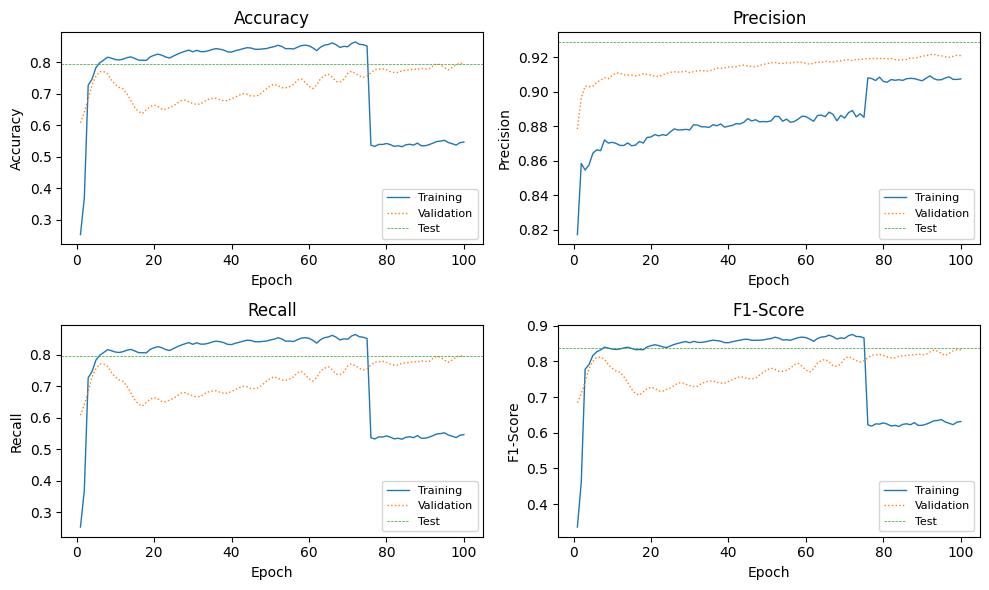

In [ ]:
plot_train_val_test_metrics(train_val_metrics, test_metrics, NUM_EPOCHS)

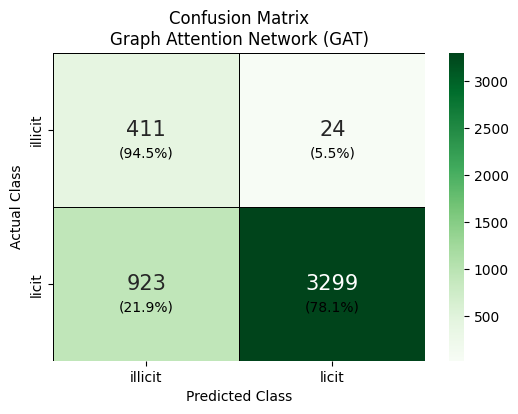

In [ ]:
test_pred = predict(model, data)[data.test_mask]

# --- Confusion matrix ---
cm = confusion_matrix(data.y[data.test_mask].cpu(), test_pred.cpu())

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='g', cmap=plt.cm.Greens,
            annot_kws={'size': 15},
            xticklabels=mapped_classes,
            yticklabels=mapped_classes,
            linecolor='black', linewidth=0.5,
            ax=ax)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

# Annotate each cell with the percentage of that row.
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percentage = cm_normalized[i, j] * 100
        text = f'\n({percentage:.1f}%)'
        color = 'white' if percentage > 95 else 'black'
        ax.text(j + 0.5, i + 0.6, text,
                ha='center', va='center', fontsize=10, color=color)

plt.title('Confusion Matrix\nGraph Attention Network (GAT)')
plt.show()

In [ ]:
train_probas = predict_probabilities(model, data)[data.train_mask]
test_probas = predict_probabilities(model, data)[data.test_mask]

In [ ]:
train_probas_illicit = train_probas[:, 1].cpu().numpy()
train_probas_illicit

array([0.9344625 , 0.96619016, 0.6260188 , ..., 0.99807173, 0.8340413 ,
       0.2178771 ], dtype=float32)

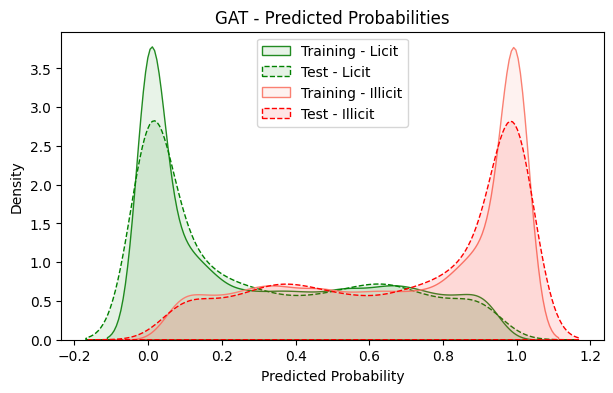

In [ ]:
ALPHA = 0.1

train_probas_licit = train_probas[:, 0].cpu().numpy()
train_probas_illicit = train_probas[:, 1].cpu().numpy()

test_probas_licit = test_probas[:, 0].cpu().numpy()
test_probas_illicit = test_probas[:, 1].cpu().numpy()

metrics_per_gnn['gat']['test']['licit']['probas'] = test_probas_licit
metrics_per_gnn['gat']['test']['illicit']['probas'] = test_probas_illicit

# -------- #
# Plotting #
# -------- #

plt.figure(figsize=(7, 4))

# Plot licit class probabilities
sns.kdeplot(train_probas_licit, fill=True, color="forestgreen", linestyle='-', alpha=ALPHA, label="Training - Licit")
sns.kdeplot(test_probas_licit, fill=True, color="green", linestyle='--', alpha=ALPHA, label="Test - Licit")

# Plot illicit class probabilities
sns.kdeplot(train_probas_illicit, fill=True, color="salmon", linestyle='-', alpha=ALPHA, label="Training - Illicit")
sns.kdeplot(test_probas_illicit, fill=True, color="red", linestyle='--', alpha=ALPHA, label="Test - Illicit")

plt.title("GAT - Predicted Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend(loc="upper center")

plt.show()

## 3️ - GIN - Graph Isomorphism Networks


In [ ]:
# -------------- #
# Define the GIN #
# -------------- #7

from torch_geometric.nn import GINConv, global_add_pool
import torch.nn.functional as F

class GIN(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GIN, self).__init__()

        # 1st GIN layer.
        nn1 = torch.nn.Sequential(
            torch.nn.Linear(num_node_features, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64)
        )
        self.conv1 = GINConv(nn1)

        # 2nd GIN layer.
        nn2 = torch.nn.Sequential(
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64)
        )
        self.conv2 = GINConv(nn2)
        self.fc = torch.nn.Linear(64, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
#         x = global_add_pool(x, batch)
        x = self.fc(x)

        return F.log_softmax(x, dim=1)

# ---------- #
# Initialize #
# ---------- #

# Tính số lượng mẫu của mỗi lớp
class_counts = torch.bincount(data.y)  # Đếm số lượng mỗi nhãn trong tập dữ liệu
class_weights = 1. / class_counts.float()  # Trọng số ngược với tần suất

# In trọng số lớp để kiểm tra
print(f"Class counts: {class_counts}")
print(f"Class weights: {class_weights}")

# Khởi tạo hàm mất mát với trọng số
criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

model = GIN(num_node_features=data.num_features, num_classes=len(le.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.0005)


data = data.to(device)

Class counts: tensor([  4545,  42019, 157205])
Class weights: tensor([2.2002e-04, 2.3799e-05, 6.3611e-06])


In [ ]:
# ----- #
# Train #
# ----- #

train_val_metrics = train_gnn(NUM_EPOCHS,
                              data,
                              model,
                              optimizer,
                              criterion)

metrics_per_gnn['gin']['val']['precisions'] = train_val_metrics['val']['precisions']

Epoch 010, Loss: 0.6218, Train - Acc: 0.5903 - Prec: 0.9150 - Rec: 0.5903 - F1: 0.6699
                         Val   - Acc: 0.6063 - Prec: 0.9069 - Rec: 0.6063 - F1: 0.6777
Epoch 020, Loss: 0.4438, Train - Acc: 0.7296 - Prec: 0.9160 - Rec: 0.7296 - F1: 0.7843
                         Val   - Acc: 0.6985 - Prec: 0.9105 - Rec: 0.6985 - F1: 0.7552
Epoch 030, Loss: 0.3438, Train - Acc: 0.8028 - Prec: 0.9232 - Rec: 0.8028 - F1: 0.8394
                         Val   - Acc: 0.8181 - Prec: 0.9196 - Rec: 0.8181 - F1: 0.8479
Epoch 040, Loss: 0.2795, Train - Acc: 0.8936 - Prec: 0.9360 - Rec: 0.8936 - F1: 0.9070
                         Val   - Acc: 0.8181 - Prec: 0.9210 - Rec: 0.8181 - F1: 0.8480
Epoch 050, Loss: 0.2175, Train - Acc: 0.9036 - Prec: 0.9432 - Rec: 0.9036 - F1: 0.9156
                         Val   - Acc: 0.9167 - Prec: 0.9373 - Rec: 0.9167 - F1: 0.9234
Epoch 060, Loss: 0.1791, Train - Acc: 0.9312 - Prec: 0.9532 - Rec: 0.9312 - F1: 0.9377
                         Val   - Acc: 0.892

In [ ]:
# -------- #
# Evaluate #
# -------- #

model.eval()
with torch.no_grad():

    test_metrics = evaluate(model, data, data.test_mask)
    test_acc = test_metrics.get('accuracy')
    test_prec = test_metrics.get('precision')
    test_rec = test_metrics.get('recall')
    test_f1 = test_metrics.get('f1_score')

    print(f'Test Acc: {test_acc:.4f} - Prec: {test_prec:.4f} - Rec: {test_rec:.4f} - F1: {test_f1:.4f}')

Test Acc: 0.9367 - Prec: 0.9519 - Rec: 0.9367 - F1: 0.9416


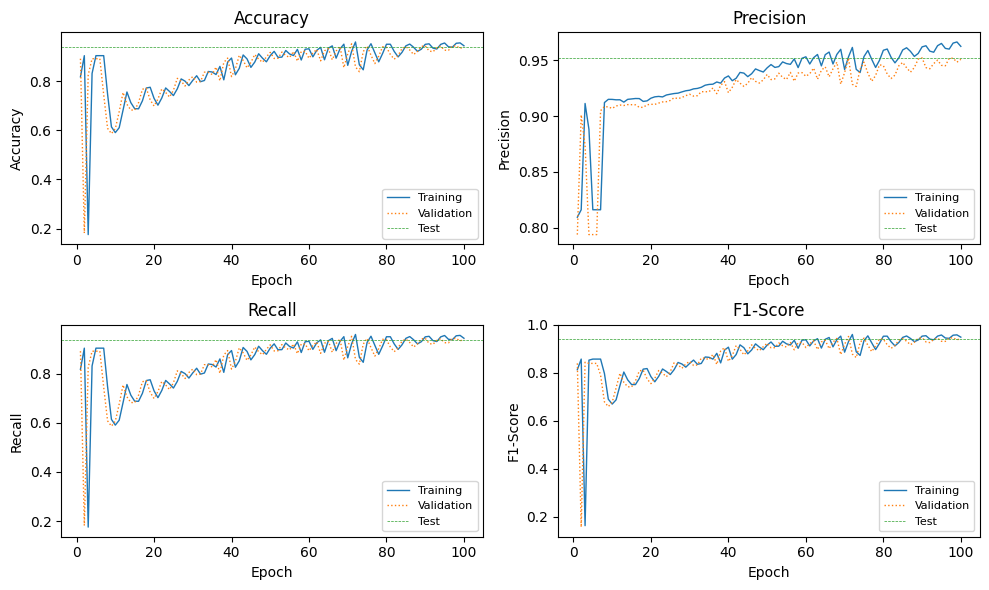

In [ ]:
plot_train_val_test_metrics(train_val_metrics, test_metrics, NUM_EPOCHS)

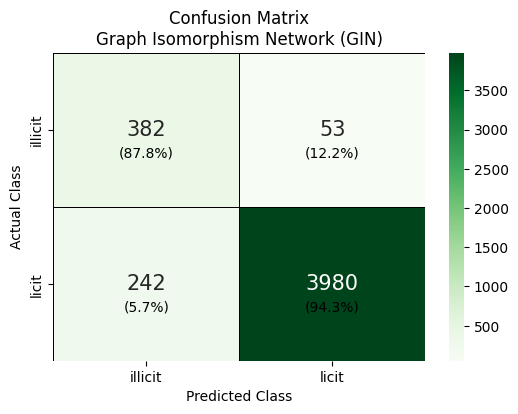

In [ ]:
test_pred = predict(model, data)[data.test_mask]

# --- Confusion matrix ---
cm = confusion_matrix(data.y[data.test_mask].cpu(), test_pred.cpu())

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='g', cmap=plt.cm.Greens,
            annot_kws={'size': 15},
            xticklabels=mapped_classes,
            yticklabels=mapped_classes,
            linecolor='black', linewidth=0.5,
            ax=ax)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

# Annotate each cell with the percentage of that row.
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percentage = cm_normalized[i, j] * 100
        text = f'\n({percentage:.1f}%)'
        color = 'white' if percentage > 95 else 'black'
        ax.text(j + 0.5, i + 0.6, text,
                ha='center', va='center', fontsize=10, color=color)

plt.title('Confusion Matrix\nGraph Isomorphism Network (GIN)')
plt.show()

In [ ]:
train_probas = predict_probabilities(model, data)[data.train_mask]
test_probas = predict_probabilities(model, data)[data.test_mask]

In [ ]:
train_probas_illicit = train_probas[:, 1].cpu().numpy()
train_probas_illicit

array([1.        , 1.        , 0.9897713 , ..., 0.9974232 , 0.9846817 ,
       0.21784441], dtype=float32)

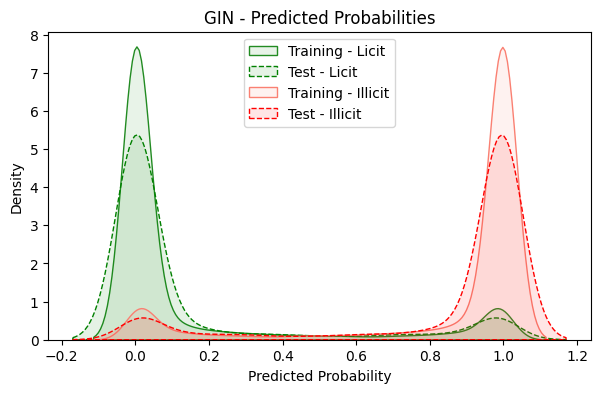

In [ ]:
ALPHA = 0.1

train_probas_licit = train_probas[:, 0].cpu().numpy()
train_probas_illicit = train_probas[:, 1].cpu().numpy()

test_probas_licit = test_probas[:, 0].cpu().numpy()
test_probas_illicit = test_probas[:, 1].cpu().numpy()

metrics_per_gnn['gin']['test']['licit']['probas'] = test_probas_licit
metrics_per_gnn['gin']['test']['illicit']['probas'] = test_probas_illicit

# -------- #
# Plotting #
# -------- #

plt.figure(figsize=(7, 4))

# Plot licit class probabilities
sns.kdeplot(train_probas_licit, fill=True, color="forestgreen", linestyle='-', alpha=ALPHA, label="Training - Licit")
sns.kdeplot(test_probas_licit, fill=True, color="green", linestyle='--', alpha=ALPHA, label="Test - Licit")

# Plot illicit class probabilities
sns.kdeplot(train_probas_illicit, fill=True, color="salmon", linestyle='-', alpha=ALPHA, label="Training - Illicit")
sns.kdeplot(test_probas_illicit, fill=True, color="red", linestyle='--', alpha=ALPHA, label="Test - Illicit")

plt.title("GIN - Predicted Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend(loc="upper center")

plt.show()

---

# Compare the GNNs

xử lý mất cân bằng => trainning GNN

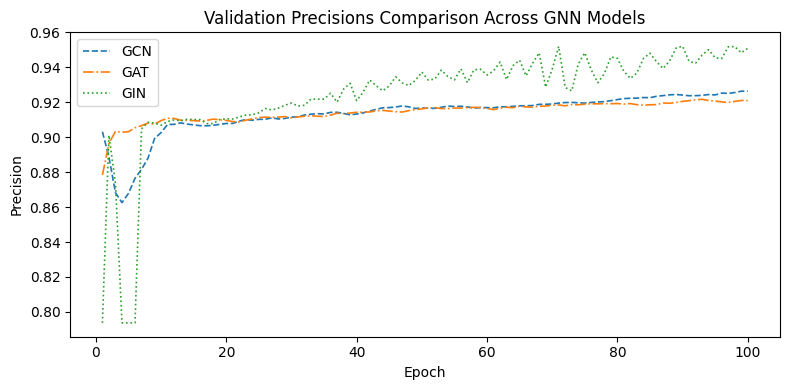

In [ ]:
plt.figure(figsize=(8, 4))

epochs = range(1, len(metrics_per_gnn['gcn']['val']['precisions']) + 1)

plt.plot(epochs, metrics_per_gnn['gcn']['val']['precisions'], color='C0', linewidth=1.2, linestyle='--', label='GCN')
plt.plot(epochs, metrics_per_gnn['gat']['val']['precisions'], color='C1', linewidth=1.2, linestyle='-.', label='GAT')
plt.plot(epochs, metrics_per_gnn['gin']['val']['precisions'], color='C2', linewidth=1.2, linestyle=':', label='GIN')

plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.title('Validation Precisions Comparison Across GNN Models')
plt.legend(fontsize=10)
plt.grid(False)
plt.tight_layout()
plt.show()

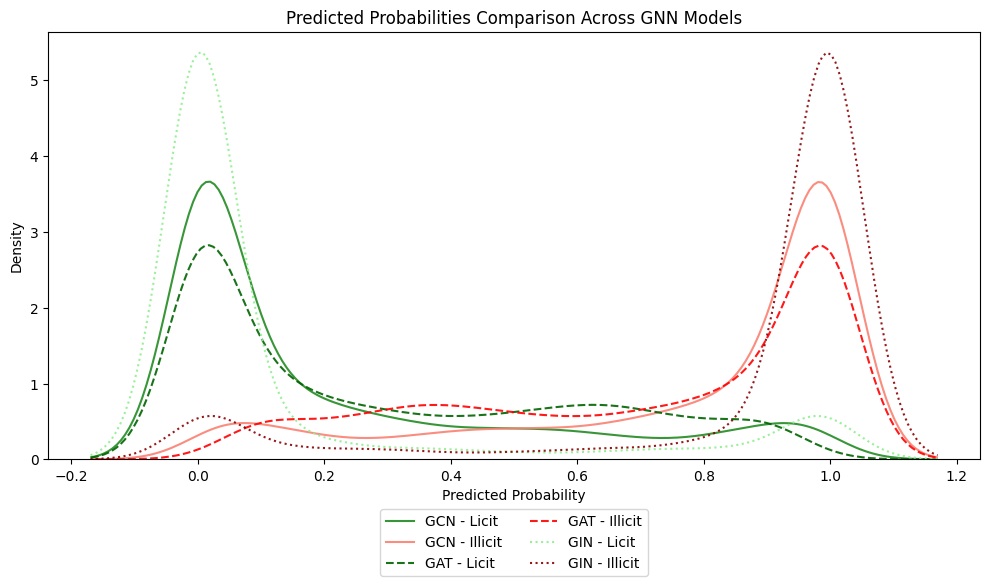

In [ ]:
ALPHA = 0.9
FILL = False

plt.figure(figsize=(10, 6))

sns.kdeplot(metrics_per_gnn['gcn']['test']['licit']['probas'], fill=FILL, color="forestgreen", linestyle='-', alpha=ALPHA, label="GCN - Licit")
sns.kdeplot(metrics_per_gnn['gcn']['test']['illicit']['probas'], fill=FILL, color="salmon", linestyle='-', alpha=ALPHA, label="GCN - Illicit")

sns.kdeplot(metrics_per_gnn['gat']['test']['licit']['probas'], fill=FILL, color="darkgreen", linestyle='--', alpha=ALPHA, label="GAT - Licit")
sns.kdeplot(metrics_per_gnn['gat']['test']['illicit']['probas'], fill=FILL, color="red", linestyle='--', alpha=ALPHA, label="GAT - Illicit")

sns.kdeplot(metrics_per_gnn['gin']['test']['licit']['probas'], fill=FILL, color="lightgreen", linestyle=':', alpha=ALPHA, label="GIN - Licit")
sns.kdeplot(metrics_per_gnn['gin']['test']['illicit']['probas'], fill=FILL, color="darkred", linestyle=':', alpha=ALPHA, label="GIN - Illicit")

plt.title("Predicted Probabilities Comparison Across GNN Models")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()

plt.show()

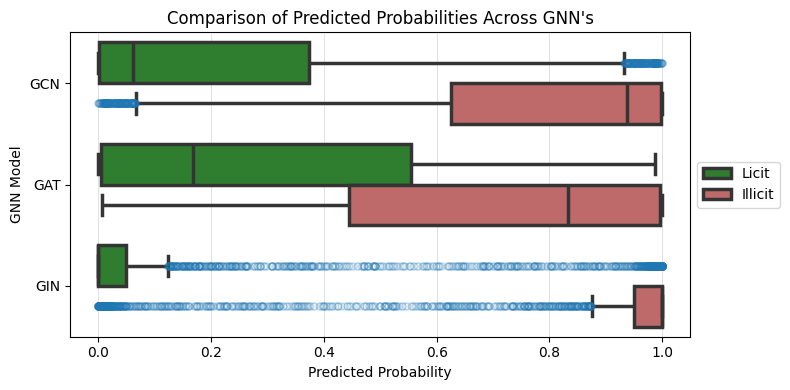

In [ ]:
data_temp = []

for model in ['gcn', 'gat', 'gin']:
    for category in ['licit', 'illicit']:
        probas = metrics_per_gnn[model]['test'][category]['probas']
        data_temp.extend([(model.upper(), category.capitalize(), proba) for proba in probas])

temp = pd.DataFrame(data_temp, columns=['Model', 'Class', 'Probability'])

plt.figure(figsize=(8, 4))

flierprops = dict(marker='o', markerfacecolor='None', markersize=5,  markeredgecolor='C0', alpha=0.2)

ax = sns.boxplot(y='Model', x='Probability', hue='Class', data=temp,
                 linewidth=2.5,
                 fliersize=0.5,
                 palette={
                     'Licit': 'forestgreen',
                     'Illicit': 'indianred'
                 },
                 flierprops=flierprops
)


plt.grid(True, which='both', axis='x', color='lightgrey', linestyle='-', linewidth=0.5)
plt.title("Comparison of Predicted Probabilities Across GNN's")
plt.xlabel("Predicted Probability")
plt.ylabel("GNN Model")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), ncol=1)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------- #
# Running a t-test to compare the means of    #
# licit vs illicit predictions for each model #
# ------------------------------------------- #

comparisons = [('gcn', 'gat'), ('gcn', 'gin'), ('gat', 'gin')]
results = []

for model1, model2 in comparisons:
    for category in ['licit', 'illicit']:
        probas1 = metrics_per_gnn[model1]['test'][category]['probas']
        probas2 = metrics_per_gnn[model2]['test'][category]['probas']
        t_stat, p_val = ttest_ind(probas1, probas2, equal_var=False)
        if p_val < 0.05:
            results.append(f"Significant difference between {model1.upper()} and {model2.upper()} for {category.capitalize()} predictions (p-value: {p_val:.4f})")

for result in results:
    print(result)

Significant difference between GCN and GAT for Licit predictions (p-value: 0.0000)
Significant difference between GCN and GAT for Illicit predictions (p-value: 0.0000)
Significant difference between GCN and GIN for Licit predictions (p-value: 0.0000)
Significant difference between GCN and GIN for Illicit predictions (p-value: 0.0000)
Significant difference between GAT and GIN for Licit predictions (p-value: 0.0000)
Significant difference between GAT and GIN for Illicit predictions (p-value: 0.0000)


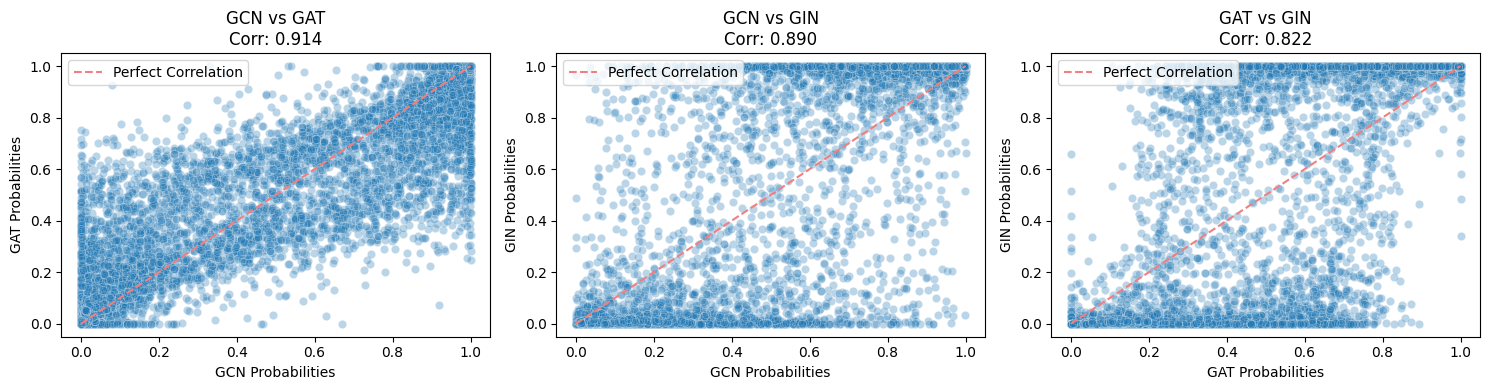

In [ ]:
combinations = [('GCN', 'GAT'), ('GCN', 'GIN'), ('GAT', 'GIN')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model1, model2) in zip(axes, combinations):
    scatter_data = pd.DataFrame({
        f'{model1}_Probabilities': temp[temp['Model'] == model1]['Probability'].values,
        f'{model2}_Probabilities': temp[temp['Model'] == model2]['Probability'].values
    })

    sns.scatterplot(
        data=scatter_data,
        x=f'{model1}_Probabilities',
        y=f'{model2}_Probabilities',
        color='C0',
        edgecolor='white',
        marker='o',
        alpha=0.3, ax=ax
    )

    corr_value = np.corrcoef(temp[temp['Model'] == model1]['Probability'],
                             temp[temp['Model'] == model2]['Probability'])[0, 1]

    ax.plot([0, 1], [0, 1], ls='--', color='lightcoral', label=f'Perfect Correlation', alpha=1.0)

    ax.set_title(f'{model1} vs {model2}\nCorr: {corr_value:.3f}')
    ax.set_xlabel(f'{model1} Probabilities')
    ax.set_ylabel(f'{model2} Probabilities')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()